In [17]:
from statistics import correlation

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize

df = pd.read_csv("../data/Premier_League/PremierLeague_Match_Data_Ready_For_ML.csv", parse_dates=['Date'])

print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 9701 entries, 0 to 9700
Data columns (total 81 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Div                                9701 non-null   str           
 1   Date                               9701 non-null   datetime64[us]
 2   HomeTeam                           9701 non-null   str           
 3   AwayTeam                           9701 non-null   str           
 4   Referee                            9701 non-null   str           
 5   Season                             9701 non-null   str           
 6   Target                             9701 non-null   int64         
 7   Home_DaysOfRest                    9701 non-null   float64       
 8   Away_DaysOfRest                    9701 non-null   float64       
 9   Home_Last5_HomePts                 9701 non-null   float64       
 10  Home_Last5_GF                      9701 non-nul

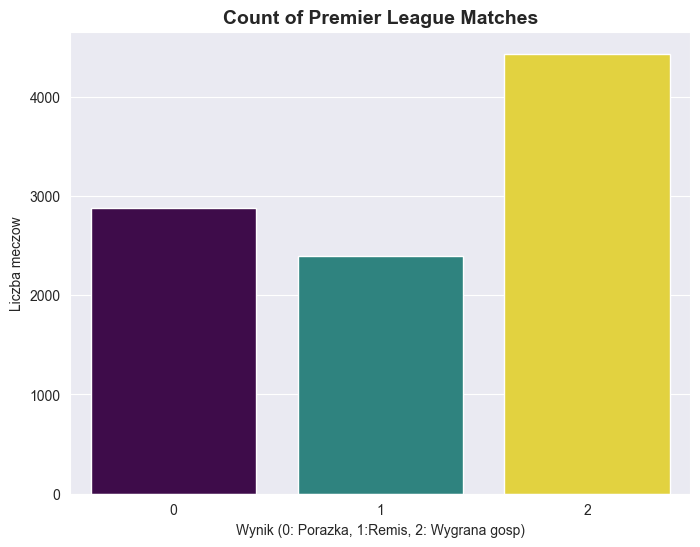

In [18]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Target',hue='Target', palette='viridis', legend=False)
plt.title('Count of Premier League Matches', fontsize=14, fontweight='bold')
plt.xlabel('Wynik (0: Porazka, 1:Remis, 2: Wygrana gosp)')
plt.ylabel('Liczba meczow')
plt.show()


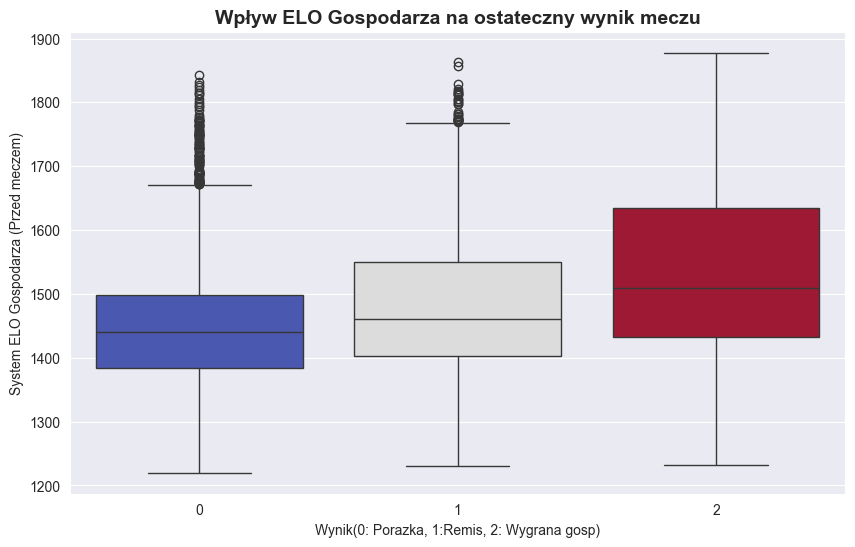

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Target', y='Home_ELO',hue='Target', palette='coolwarm', legend=False)
plt.title('Wpływ ELO Gospodarza na ostateczny wynik meczu', fontsize=14, fontweight='bold')
plt.xlabel('Wynik(0: Porazka, 1:Remis, 2: Wygrana gosp)')
plt.ylabel('System ELO Gospodarza (Przed meczem)')
plt.show()

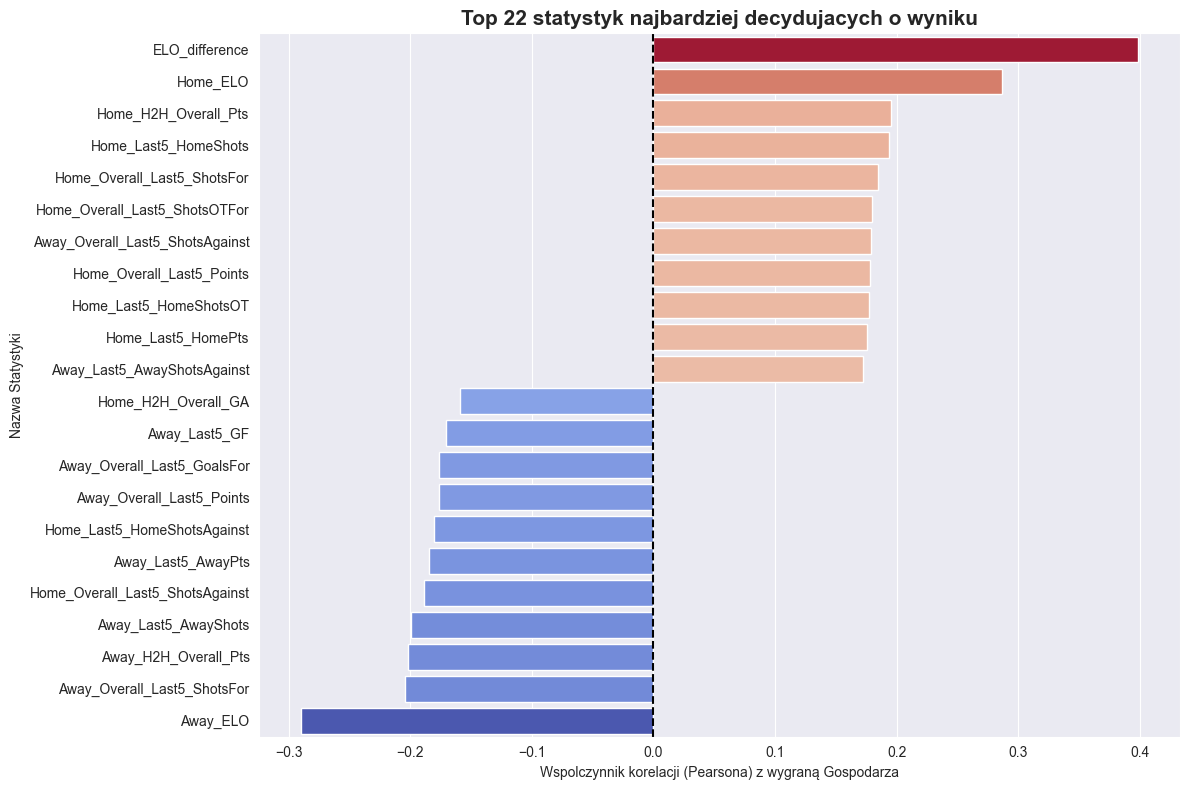

In [62]:
numeric_cols = df.select_dtypes(include=['float64','int64'])

corr_with_target = numeric_cols.corr()['Target'].drop('Target').sort_values(ascending=False)

top_features= pd.concat([corr_with_target.head(11), corr_with_target.tail(11)])
plt.figure(figsize=(12,8))

sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.values, palette='coolwarm', legend=False)
plt.title('Top 22 statystyk najbardziej decydujacych o wyniku', fontsize=15, fontweight='bold')
plt.xlabel('Wspolczynnik korelacji (Pearsona) z wygraną Gospodarza')
plt.ylabel('Nazwa Statystyki')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [22]:
df['Rest_Advantage']= df['Home_DaysOfRest'] - df['Away_DaysOfRest']

In [23]:
def categorize_rest(diff):
    if diff <= -3: return "1. Mocno zmęczony (<= -3 dni)"
    elif diff in [-2, -1]: return "2. Lekko zmęczony (-1, -2 dni)"
    elif diff == 0: return "3. Równe szanse (0 dni)"
    elif diff in [1,2]: return "4. Lekko wypoczęty (+1, +2 dni)"
    else: return "5. Mocno wypoczęty (>= +3 dni)"

In [24]:
df['Rest_Bucket'] = df['Rest_Advantage'].apply(categorize_rest)
rest_stats = df.groupby('Rest_Bucket')['Target'].apply(lambda x: (x== 2).mean() * 100).reset_index()
rest_stats.rename(columns={'Target':'WinPercentage'}, inplace=True)
rest_stats = rest_stats.sort_values(by='Rest_Bucket', ascending=False)

Text(0, 0.5, 'Procent wygranych meczów (%)')

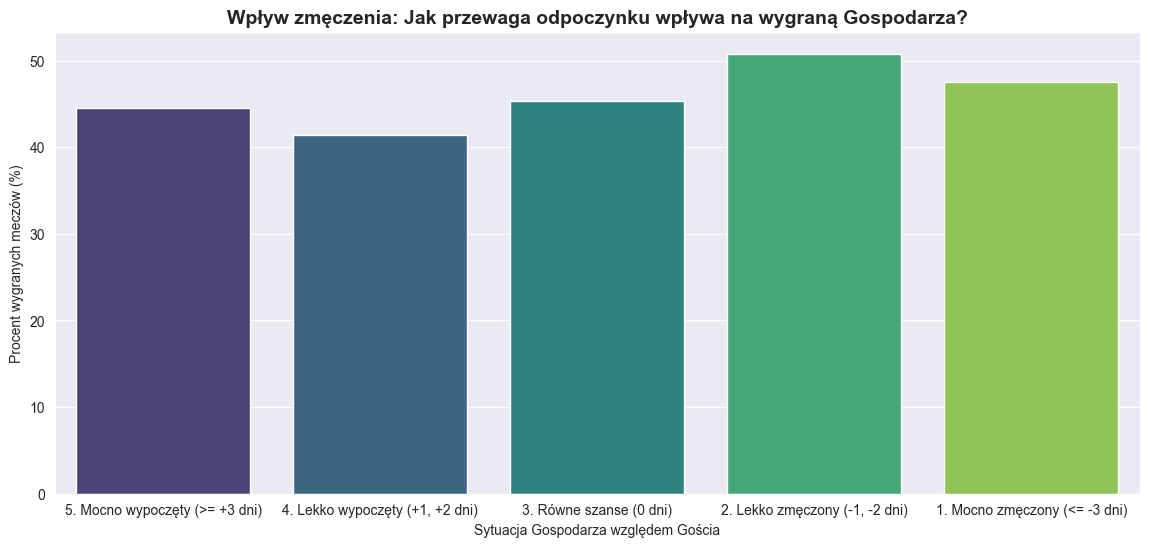

In [27]:
plt.figure(figsize=(14,6))
sns.barplot(data=rest_stats, x='Rest_Bucket',y='WinPercentage',hue='Rest_Bucket', palette='viridis', legend=False)
plt.title('Wpływ zmęczenia: Jak przewaga odpoczynku wpływa na wygraną Gospodarza?', fontsize=14, fontweight='bold')
plt.xlabel('Sytuacja Gospodarza względem Gościa')
plt.ylabel('Procent wygranych meczów (%)')

In [53]:
import numpy as np

numeric_cols = df.select_dtypes(include= ['float64', 'int64'])
correlations_with_target = numeric_cols.corr()['Target'].abs().drop('Target').sort_values(ascending=False)
top_15_features = correlations_with_target.head(30).index.tolist()


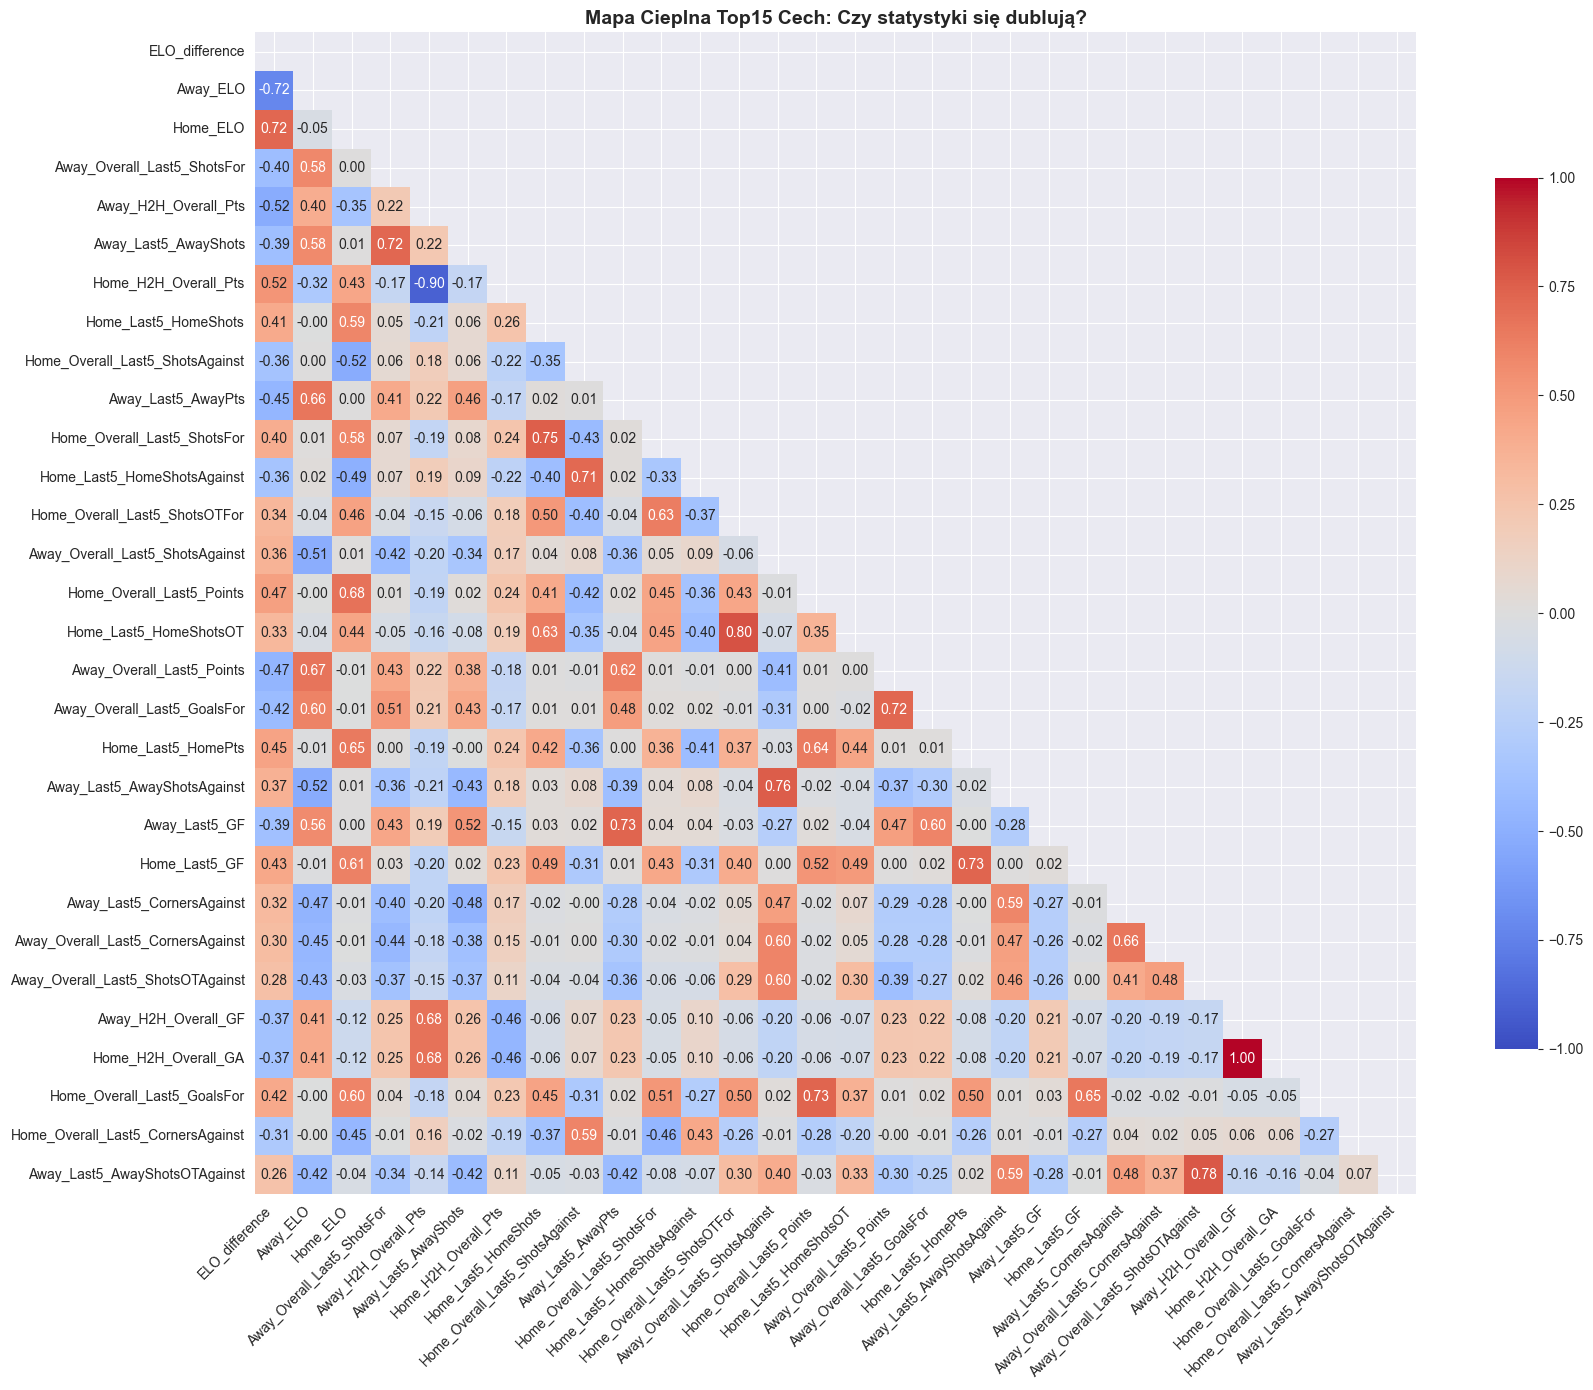

In [54]:
corr_matrix = df[top_15_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18,14))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar_kws={'shrink': .75})

plt.title('Mapa Cieplna Top15 Cech: Czy statystyki się dublują?', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*TODO DELETE H2H AWAY*

In [55]:
season_stats = df.groupby('Season')['Target'].value_counts(normalize=True).unstack() * 100

season_stats.rename(columns = {
    0: 'Wygrana Gości (Away Win)',
    1: 'Remis (Draw)',
    2: 'Wygrana Gospodarza (Home Win)'
}, inplace=True)

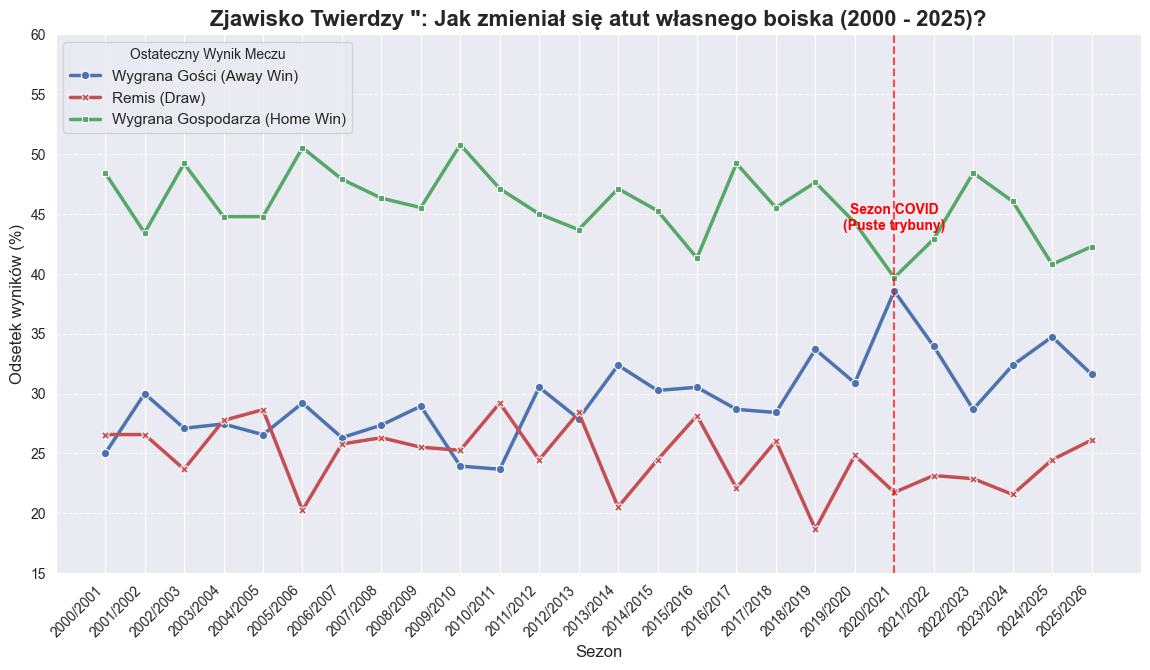

In [61]:
plt.figure(figsize=(14,7))
sns.lineplot(data=season_stats,markers=True,dashes=False,linewidth=2.5,palette=['#4c72b0', '#c44e52', '#55a868'])

plt.title('Zjawisko Twierdzy ": Jak zmieniał się atut własnego boiska (2000 - 2025)?',fontsize=16, fontweight='bold')
plt.xlabel('Sezon',fontsize=12)
plt.ylabel('Odsetek wyników (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
if '2020/2021' in season_stats.index:
    plt.axvline(x='2020/2021', color='red', linestyle='--', alpha=0.7)
    y_val = season_stats.loc['2020/2021', 'Wygrana Gospodarza (Home Win)']
    plt.text('2020/2021', y_val + 4, 'Sezon COVID\n(Puste trybuny)',color = 'red', ha='center', fontweight='bold')

plt.legend(title='Ostateczny Wynik Meczu', fontsize=11)
plt.ylim(15,60)
plt.grid(axis='y', linestyle='--',alpha=0.7)
plt.show()

In [66]:
teams_to_plot = ['Man United', 'Man City', 'Arsenal', 'Chelsea']
elo_data = df[df['HomeTeam'].isin(teams_to_plot)][['Date', 'HomeTeam','Home_ELO']].copy()
elo_data.rename(columns={'HomeTeam':'Team', 'Home_ELO':'ELO'}, inplace=True)

elo_data['Smoothed_ELO']=elo_data.groupby('Team')['ELO'].transform(lambda x: x.rolling(10,min_periods=1).mean())

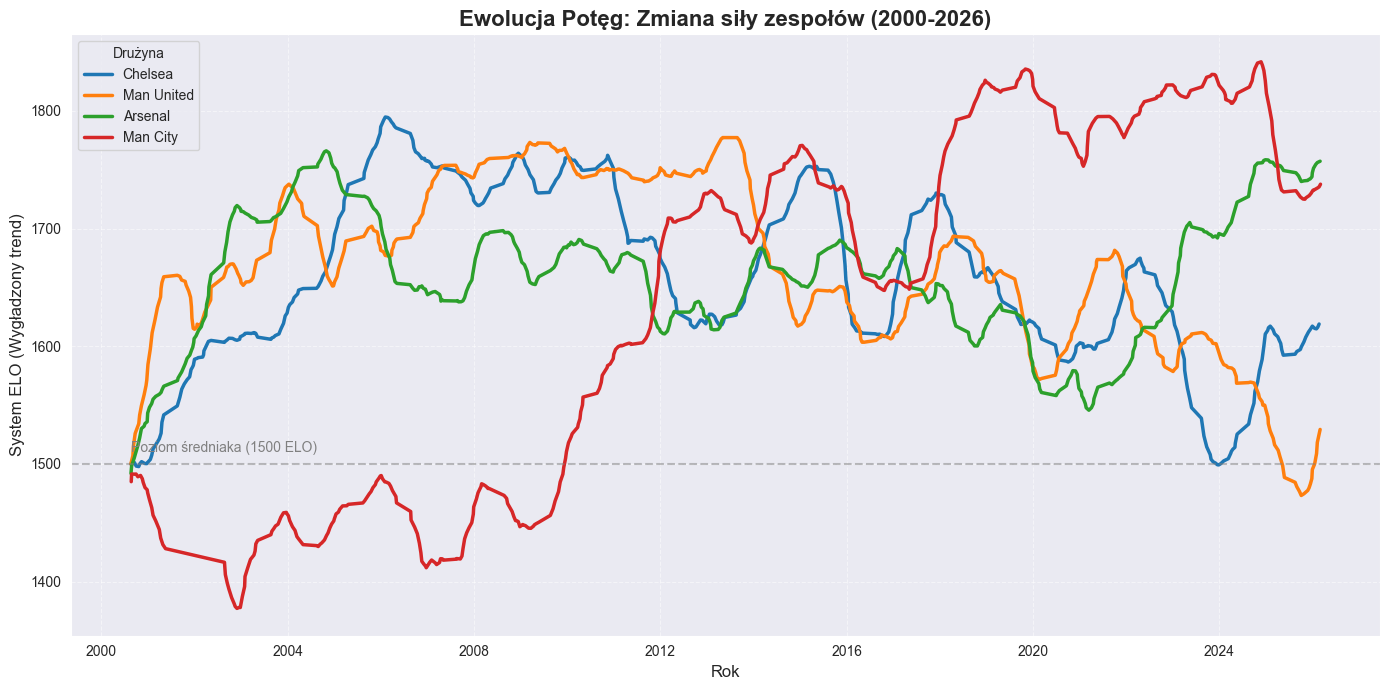

In [68]:
plt.figure(figsize=(14,7))
sns.lineplot(data=elo_data, x='Date', y='Smoothed_ELO',hue='Team',linewidth=2.5,palette='tab10')
plt.title('Ewolucja Potęg: Zmiana siły zespołów (2000-2026)',fontsize=16, fontweight='bold')
plt.xlabel('Rok',fontsize=12)
plt.ylabel('System ELO (Wygładzony trend)', fontsize=12)

plt.axhline(y=1500,color='gray',linestyle='--',alpha=0.5)
plt.text(elo_data['Date'].min(),1510,'Poziom średniaka (1500 ELO)',color='gray')
plt.legend(title='Drużyna',loc='upper left')
plt.grid(axis='both', linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()